In [84]:
import pandas as pd
from matplotlib import pyplot as plt
from prophet import Prophet
from datetime import datetime
from prophet.diagnostics import cross_validation, performance_metrics
import matplotlib.pyplot as plt
import itertools

In [40]:
df = pd.read_csv('./data/fct_campaign.csv')
df

,date,platform,campaign_type,campaign_id,channel,target_segment,objective,expected_uplift,country,impressions,clicks,CTR,ad_spend,conversions,ROAS,revenue,conversion_lift,click_to_conversion_rate
0,2021-01-20,NaN,NaN,12.0,Email,Churn Risk,Acquisition,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-31,NaN,NaN,44.0,Affiliate,All,Reactivation,0.141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-02-14,NaN,NaN,50.0,Email,Churn Risk,Retention,0.023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-03-19,NaN,NaN,25.0,Paid Search,High Value,Cross-sell,0.119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-04-09,NaN,NaN,49.0,Paid Search,Deal Seekers,Reactivation,0.128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1845,2024-12-30,Meta Ads,Display,NaN,NaN,NaN,NaN,NaN,USA,108152.0,4250.0,0.0393,3060.00,160.0,4.07,12452.25,NaN,0.037647
1846,2024-12-30,Meta Ads,Search,NaN,NaN,NaN,NaN,NaN,UAE,18487.0,693.0,0.0375,339.57,36.0,22.87,7765.15,NaN,0.051948
1847,2024-12-30,TikTok Ads,Video,NaN,NaN,NaN,NaN,NaN,India,194407.0,13122.0,0.0675,11153.70,379.0,5.05,56289.95,NaN,0.028883
1848,2024-12-30,TikTok Ads,Search,NaN,NaN,NaN,NaN,NaN,Germany,196349.0,8325.0,0.0424,5744.25,398.0,7.39,42464.91,NaN,0.047808


In [137]:
df_clean = df[["date", "country", "impressions", "clicks", "CTR", "ad_spend", "conversions", "revenue"]]
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.rename(columns={"date": "ds"})
df_clean = df_clean.dropna(subset=['revenue'])
# df.head(10)
df_clean['country'].unique()

<StringArray>
['USA', 'India', 'UK', 'Germany', 'Canada', 'UAE', 'Australia']
Length: 7, dtype: str

In [138]:
# North America Data
df_na = df_clean[(df_clean['country']=='USA')]
# print(df_na)


# Sum the revenue
# df_daily = df.groupby('ds')['Revenue'].sum().reset_index()
for re in regressors:
    df_daily = df_clean.groupby('ds').agg({
        'impressions': 'sum',
        'clicks': 'sum',
        'CTR': 'sum',
        'ad_spend': 'sum',
        'conversions': 'sum',
        'revenue': 'sum'
    }).reset_index()


df_daily = df_daily.sort_values('ds')
df_daily = df_daily.rename(columns={'revenue': 'y'})

# print(df_daily)
# print(df_daily.columns)

In [139]:
# Including Black Friday
black_friday = pd.DataFrame({
  'holiday': 'black_friday',
  'ds': pd.to_datetime(['2024-11-29']),
  'lower_window': 0,
  'upper_window': 3, 
})

14:49:37 - cmdstanpy - INFO - Chain [1] start processing
14:49:37 - cmdstanpy - INFO - Chain [1] done processing


            ds           yhat    yhat_lower     yhat_upper
385 2025-01-25  149922.768977  80260.335964  212338.929036
386 2025-01-26  146934.970070  81268.441011  218421.966305
387 2025-01-27  142282.642769  75595.960749  211720.250144
388 2025-01-28  143717.762316  73866.990432  206250.032627
389 2025-01-29  150114.339618  86535.939687  218033.148430


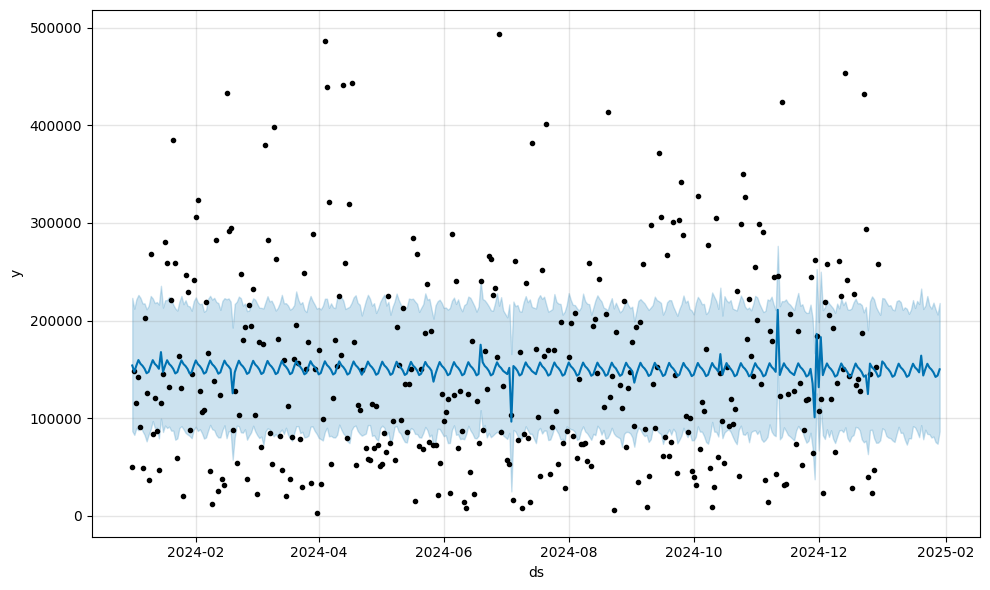

  0%|          | 0/6 [00:00<?, ?it/s]14:49:37 - cmdstanpy - INFO - Chain [1] start processing
14:49:37 - cmdstanpy - INFO - Chain [1] done processing
14:49:37 - cmdstanpy - INFO - Chain [1] start processing
14:49:37 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 15.91it/s]14:49:37 - cmdstanpy - INFO - Chain [1] start processing
14:49:37 - cmdstanpy - INFO - Chain [1] done processing
14:49:37 - cmdstanpy - INFO - Chain [1] start processing
14:49:37 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 15.58it/s]14:49:37 - cmdstanpy - INFO - Chain [1] start processing
14:49:37 - cmdstanpy - INFO - Chain [1] done processing
14:49:37 - cmdstanpy - INFO - Chain [1] start processing
14:49:37 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:00<00:00, 15.09it/s]


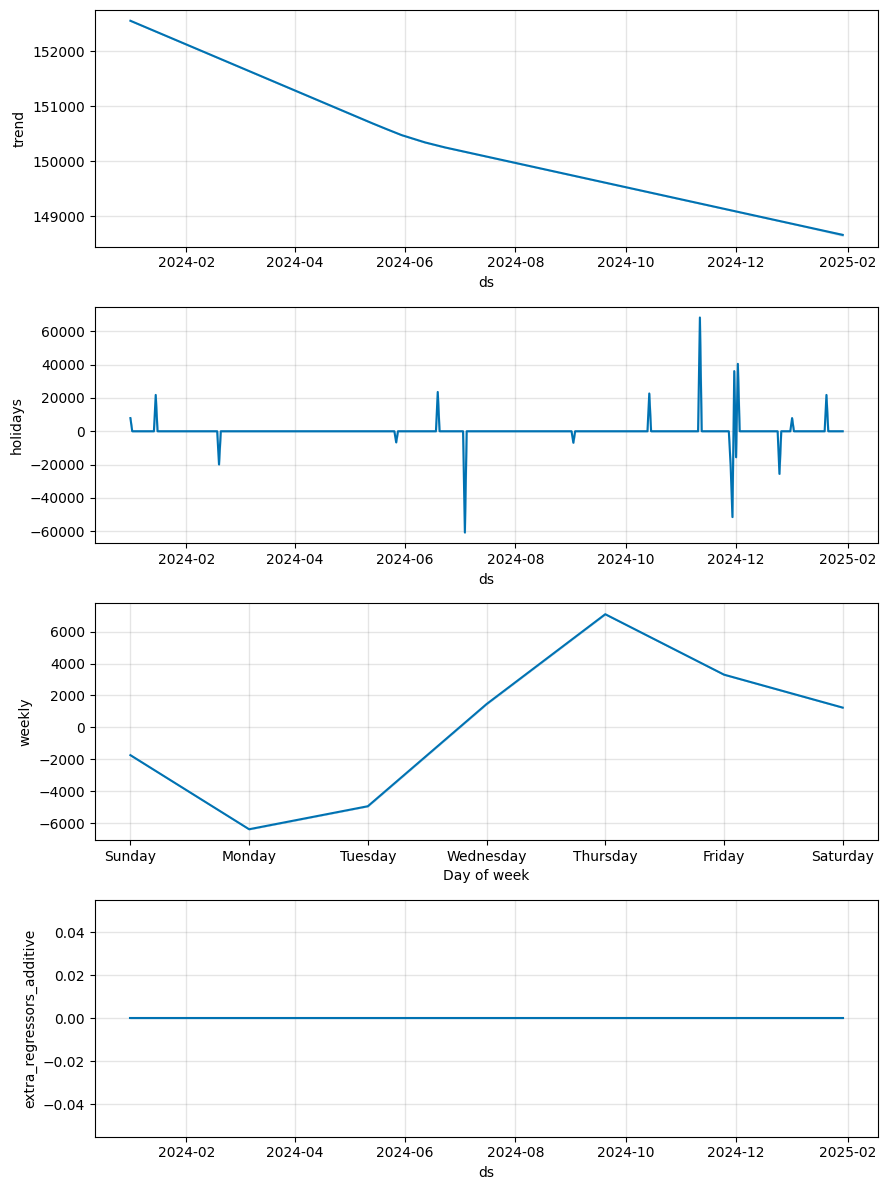

Accuracy (30 days): 85.50%


In [140]:
# Model 1 for USA

params = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
}

m = Prophet(interval_width = 0.90, holidays=black_friday)
# m = Prophet(interval_width = 0.90)


# m.add_seasonality(name='weekly', period=7, fourier_order=10, prior_scale=0.1)
m.add_country_holidays(country_name='US')

regressors = ["impressions", "clicks", "CTR", "ad_spend", "conversions"]

for regressor in regressors:
    m.add_regressor(regressor)

m.fit(df_daily)

future = m.make_future_dataframe(periods=30)

for futures in regressors:
    future[futures] = df_daily[futures].mean()

forecast = m.predict(future)
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())
# print(forecast.tail())

fig = m.plot(forecast)
plt.show()

df_cv = cross_validation(
    m, 
    initial='180 days',   
    period='30 days',    
    horizon='30 days'    
)

# Calculate performance metrics
df_p = performance_metrics(df_cv)
# print(df_p)

fig2 = m.plot_components(forecast)
plt.show()

# Calculate Accuracy
df_p['accuracy_smape'] = (1 - (df_p['smape'] / 2)) * 100

overall_accuracy = df_p['accuracy_smape'].mean()

print(f"Accuracy (30 days): {overall_accuracy:.2f}%")


In [136]:
print(m.train_holiday_names)

0                             black_friday
1                           New Year's Day
2                             Memorial Day
3     Juneteenth National Independence Day
4                         Independence Day
5                                Labor Day
6                         Thanksgiving Day
7                            Christmas Day
8               Martin Luther King Jr. Day
9                    Washington's Birthday
10                            Columbus Day
11                            Veterans Day
dtype: str
